# Analyse du catalogue Netflix
8PRO408 — Projet de session

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def linregress_np(x, y):
    """Remplace scipy.stats.linregress : pente, intercept, r, p, std_err."""
    x = np.asarray(x, float); y = np.asarray(y, float)
    n = len(x)
    slope, intercept = np.polyfit(x, y, 1)
    r = np.corrcoef(x, y)[0, 1]
    # p-value (test t bilateral sur la pente)
    from math import erf, sqrt
    if n > 2 and abs(r) < 1:
        t = r * sqrt((n - 2) / (1 - r**2))
        # approximation normale de la p-value (suffisant pour de gros n)
        p = 2 * (1 - 0.5 * (1 + erf(abs(t) / sqrt(2))))
    else:
        t, p = float("nan"), float("nan")
    std_err = slope / t if t else float("nan")
    return slope, intercept, r, p, std_err

## 1. Chargement et nettoyage

In [2]:
# le fichier a des lignes mal formatees dans la colonne Overview
# on utilise engine='python' + on_bad_lines='skip' pour les ignorer
df = pd.read_csv("data/netflix.csv", engine="python", on_bad_lines="skip")
print(df.shape)
df.head()

(9837, 9)


,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022-03-01,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022-02-25,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021-11-24,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021-12-22,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


In [3]:
print(df.dtypes)
print()
print(df.isnull().sum())

Release_Date             str
Title                    str
Overview                 str
Popularity           float64
Vote_Count               str
Vote_Average             str
Original_Language        str
Genre                    str
Poster_Url               str
dtype: object

Release_Date          0
Title                 9
Overview              9
Popularity           10
Vote_Count           10
Vote_Average         10
Original_Language    10
Genre                11
Poster_Url           11
dtype: int64


In [4]:
# Vote_Count et Vote_Average sont lus en string a cause des lignes corrompues
df["Vote_Count"] = pd.to_numeric(df["Vote_Count"], errors="coerce")
df["Vote_Average"] = pd.to_numeric(df["Vote_Average"], errors="coerce")

# convertir la date et extraire l'annee
df["Release_Date"] = pd.to_datetime(df["Release_Date"], errors="coerce")
df["year"] = df["Release_Date"].dt.year

# extraire le genre principal (le premier de la liste)
df["main_genre"] = df["Genre"].str.split(",").str[0].str.strip()

# supprimer les lignes sans note ni votes (inutilisables pour la regression)
df = df.dropna(subset=["Vote_Average", "Vote_Count", "Popularity"])
print(f"apres nettoyage : {df.shape}")
df.dtypes

apres nettoyage : (9826, 11)


Release_Date         datetime64[us]
Title                           str
Overview                        str
Popularity                  float64
Vote_Count                  float64
Vote_Average                float64
Original_Language               str
Genre                           str
Poster_Url                      str
year                        float64
main_genre                   object
dtype: object

In [5]:
df.describe()

,Release_Date,Popularity,Vote_Count,Vote_Average,year
count,9826,9826.000000,9826.000000,9826.000000,9826.000000
mean,2006-09-23 04:47:14.276409,40.323951,1392.943721,6.439467,2006.202931
min,1902-04-17 00:00:00,13.354000,0.000000,0.000000,1902.000000
25%,2000-10-17 12:00:00,16.128250,146.000000,5.900000,2000.000000
50%,2011-09-12 00:00:00,21.195000,444.000000,6.500000,2011.000000
75%,2017-11-22 00:00:00,35.179250,1376.000000,7.100000,2017.000000
max,2024-07-03 00:00:00,5083.954000,31077.000000,10.000000,2024.000000
std,NaN,108.879332,2611.303856,1.129797,15.686202


## 2. Exploration

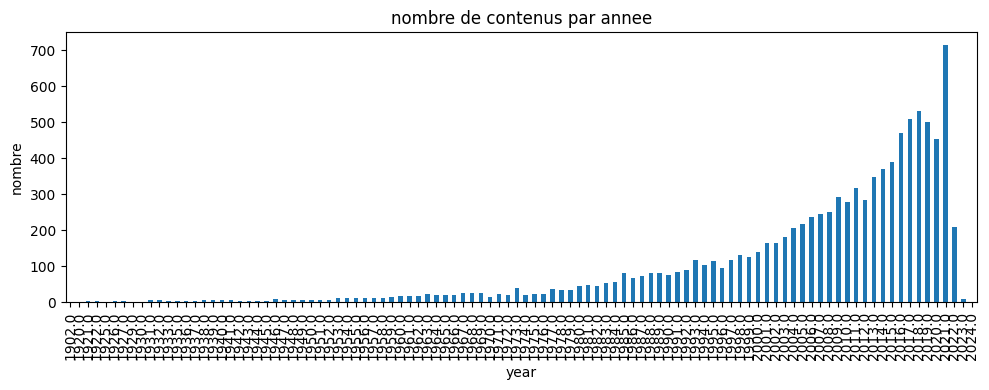

In [6]:
# nombre de films par annee
films_par_an = df.groupby("year").size()
fig, ax = plt.subplots(figsize=(10, 4))
films_par_an.plot(kind="bar", ax=ax)
ax.set_title("nombre de contenus par annee")
ax.set_ylabel("nombre")
plt.tight_layout()
plt.show()

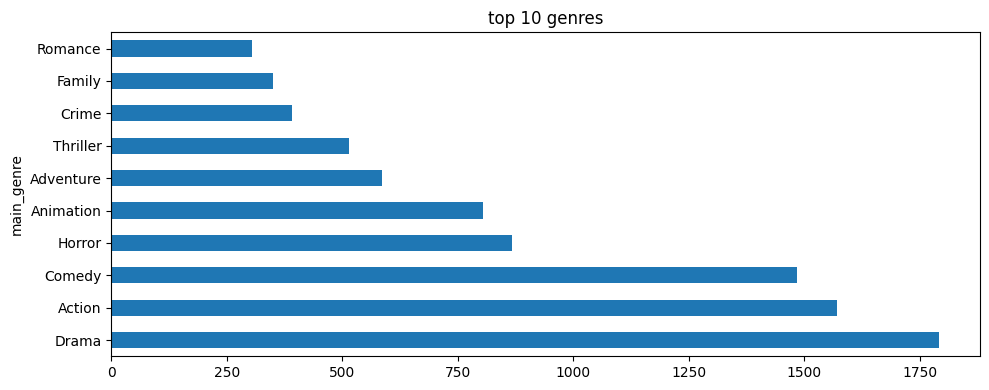

In [7]:
# top 10 genres
top_genres = df["main_genre"].value_counts().head(10)
fig, ax = plt.subplots(figsize=(10, 4))
top_genres.plot(kind="barh", ax=ax)
ax.set_title("top 10 genres")
plt.tight_layout()
plt.show()

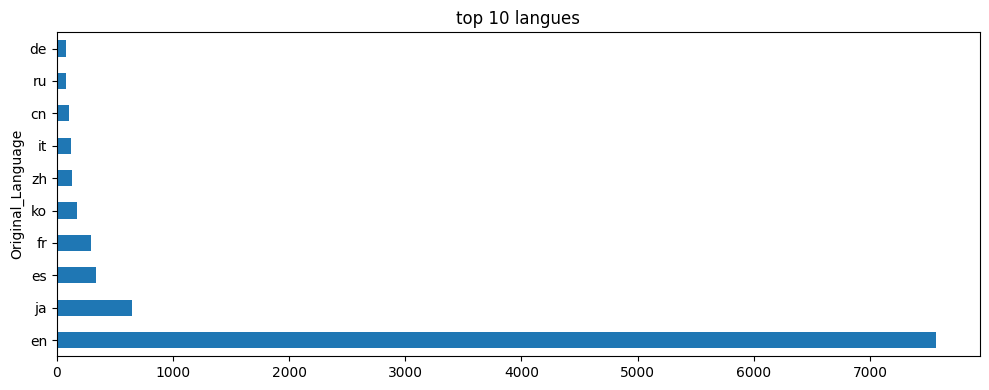

In [8]:
# top 10 langues
top_lang = df["Original_Language"].value_counts().head(10)
fig, ax = plt.subplots(figsize=(10, 4))
top_lang.plot(kind="barh", ax=ax)
ax.set_title("top 10 langues")
plt.tight_layout()
plt.show()

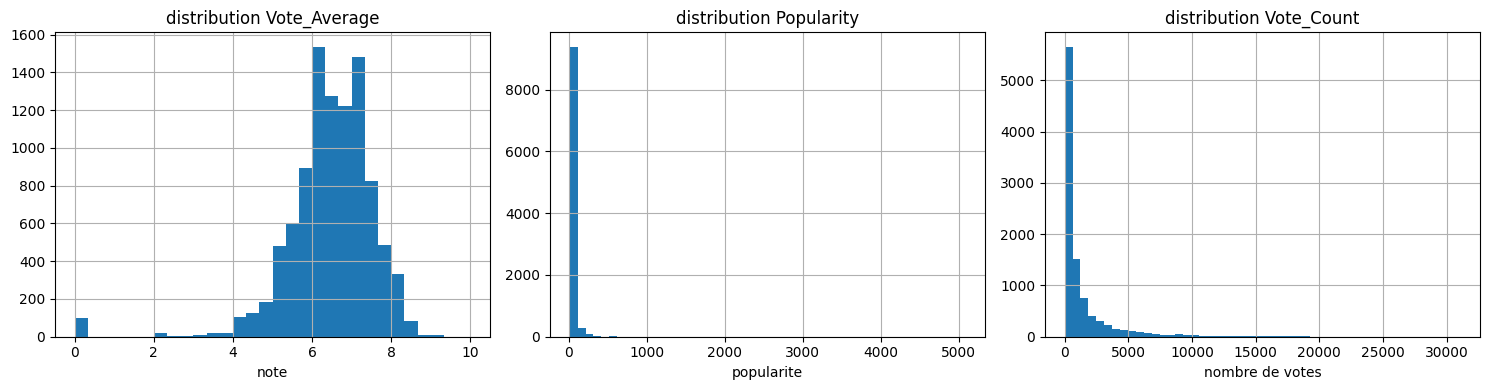

In [9]:
# distribution des notes
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df["Vote_Average"].hist(bins=30, ax=axes[0])
axes[0].set_title("distribution Vote_Average")
axes[0].set_xlabel("note")

df["Popularity"].hist(bins=50, ax=axes[1])
axes[1].set_title("distribution Popularity")
axes[1].set_xlabel("popularite")

df["Vote_Count"].hist(bins=50, ax=axes[2])
axes[2].set_title("distribution Vote_Count")
axes[2].set_xlabel("nombre de votes")

plt.tight_layout()
plt.show()

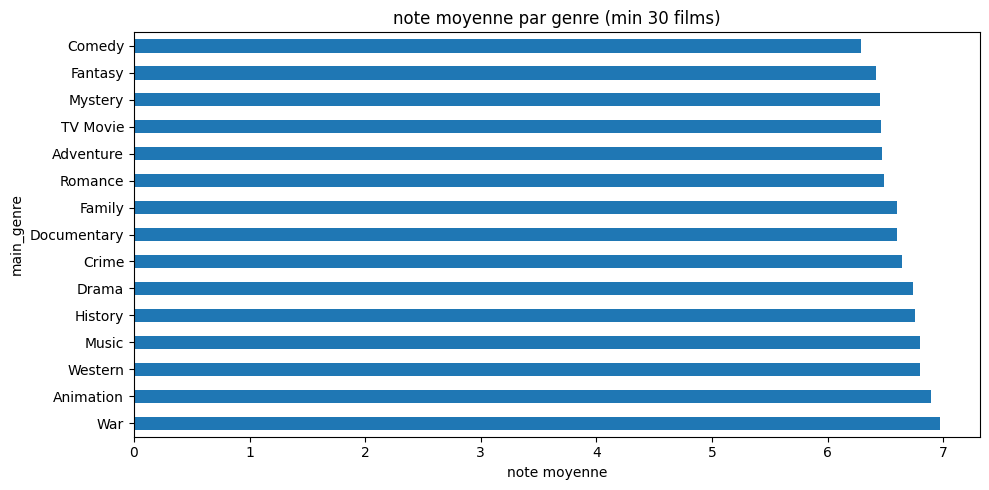

In [10]:
# note moyenne par genre (top 10)
genre_stats = df.groupby("main_genre").agg(
    note_moy=("Vote_Average", "mean"),
    nb_films=("Title", "count")
).query("nb_films >= 30").sort_values("note_moy", ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
genre_stats["note_moy"].head(15).plot(kind="barh", ax=ax)
ax.set_xlabel("note moyenne")
ax.set_title("note moyenne par genre (min 30 films)")
plt.tight_layout()
plt.show()

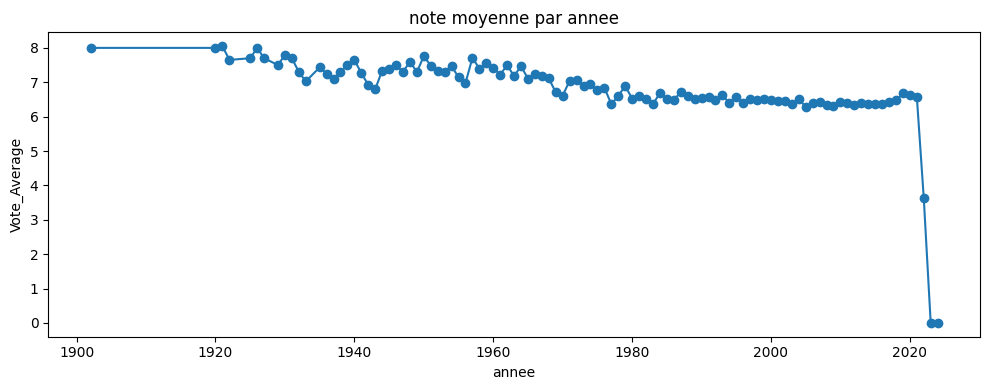

In [11]:
# evolution de la note moyenne par annee
note_par_an = df.groupby("year")["Vote_Average"].mean()
fig, ax = plt.subplots(figsize=(10, 4))
note_par_an.plot(ax=ax, marker="o")
ax.set_title("note moyenne par annee")
ax.set_ylabel("Vote_Average")
ax.set_xlabel("annee")
plt.tight_layout()
plt.show()

## 3. Correlations

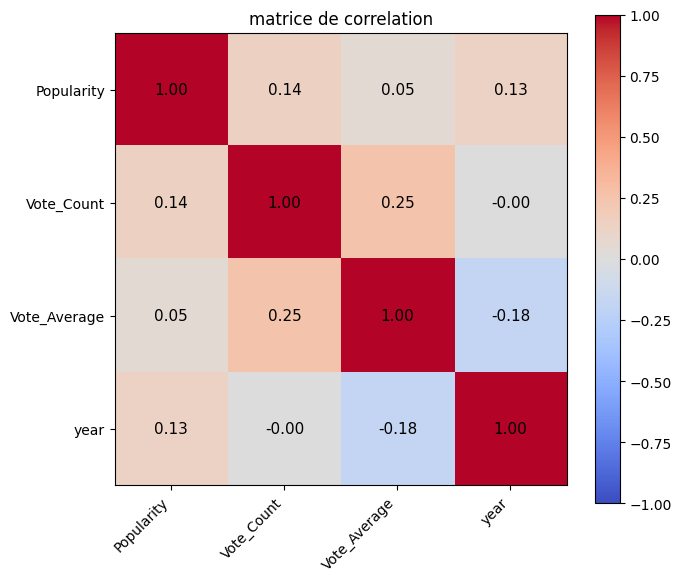

In [12]:
# matrice de correlation sur les colonnes numeriques
num_cols = ["Popularity", "Vote_Count", "Vote_Average", "year"]
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(num_cols)))
ax.set_yticks(range(len(num_cols)))
ax.set_xticklabels(num_cols, rotation=45, ha="right")
ax.set_yticklabels(num_cols)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.iloc[i,j]:.2f}", ha="center", va="center", fontsize=11)
plt.colorbar(im)
ax.set_title("matrice de correlation")
plt.tight_layout()
plt.show()

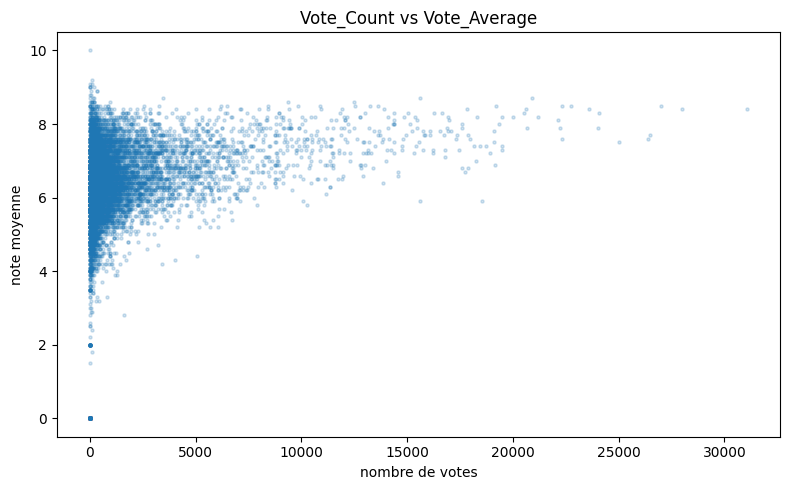

correlation : 0.2536


In [13]:
# scatter : Vote_Count vs Vote_Average
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df["Vote_Count"], df["Vote_Average"], alpha=0.2, s=5)
ax.set_xlabel("nombre de votes")
ax.set_ylabel("note moyenne")
ax.set_title("Vote_Count vs Vote_Average")
plt.tight_layout()
plt.show()

r = df[["Vote_Count", "Vote_Average"]].corr().iloc[0,1]
print(f"correlation : {r:.4f}")

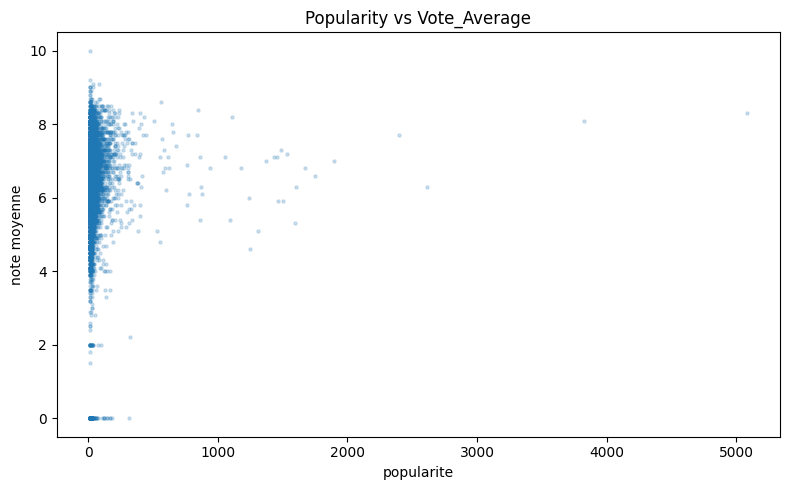

correlation : 0.0538


In [14]:
# scatter : Popularity vs Vote_Average
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df["Popularity"], df["Vote_Average"], alpha=0.2, s=5)
ax.set_xlabel("popularite")
ax.set_ylabel("note moyenne")
ax.set_title("Popularity vs Vote_Average")
plt.tight_layout()
plt.show()

r = df[["Popularity", "Vote_Average"]].corr().iloc[0,1]
print(f"correlation : {r:.4f}")

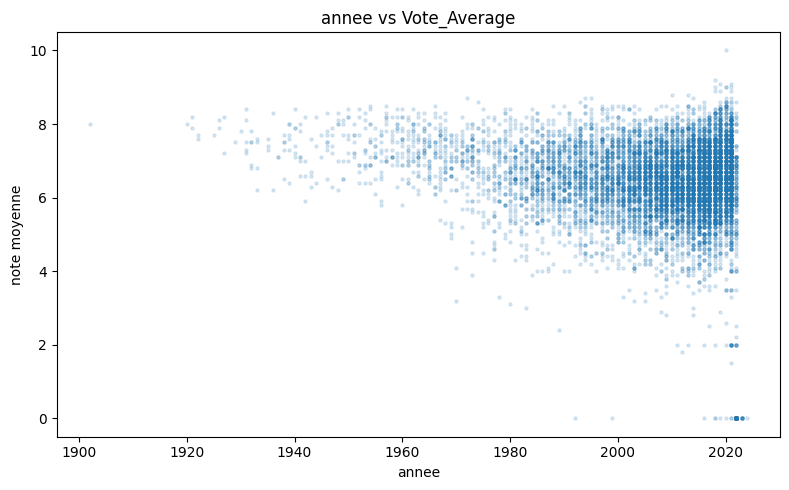

correlation : -0.1751


In [15]:
# scatter : annee vs note
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df["year"], df["Vote_Average"], alpha=0.15, s=5)
ax.set_xlabel("annee")
ax.set_ylabel("note moyenne")
ax.set_title("annee vs Vote_Average")
plt.tight_layout()
plt.show()

r = df[["year", "Vote_Average"]].dropna().corr().iloc[0,1]
print(f"correlation : {r:.4f}")

## 4. Regression

Vote_Count -> Vote_Average
pente=0.000110, intercept=6.2866
R2=0.0643, p=0.00e+00


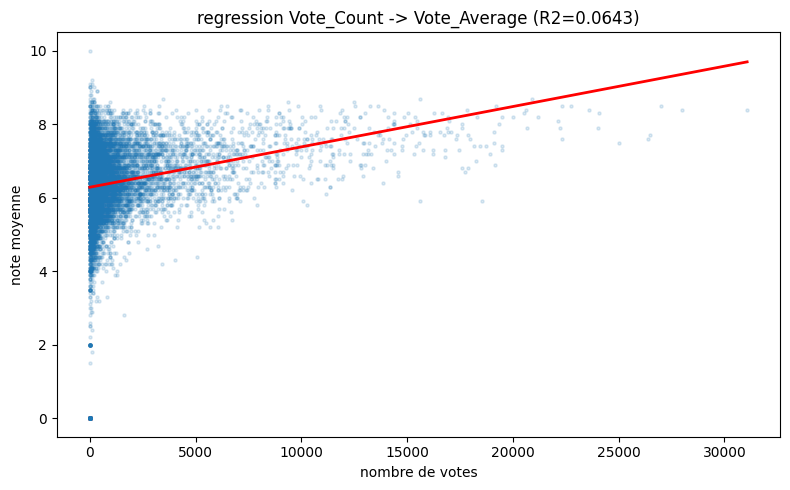

In [16]:
# regression lineaire : Vote_Count -> Vote_Average
clean = df.dropna(subset=["Vote_Count", "Vote_Average"])
x = clean["Vote_Count"].values
y = clean["Vote_Average"].values

slope, intercept, r_value, p_value, std_err = linregress_np(x, y)
print(f"Vote_Count -> Vote_Average")
print(f"pente={slope:.6f}, intercept={intercept:.4f}")
print(f"R2={r_value**2:.4f}, p={p_value:.2e}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(x, y, alpha=0.15, s=5)
x_line = np.linspace(x.min(), x.max(), 100)
ax.plot(x_line, slope * x_line + intercept, color="red", linewidth=2)
ax.set_xlabel("nombre de votes")
ax.set_ylabel("note moyenne")
ax.set_title(f"regression Vote_Count -> Vote_Average (R2={r_value**2:.4f})")
plt.tight_layout()
plt.show()

Popularity -> Vote_Average
pente=0.000559, intercept=6.4169
R2=0.0029, p=9.12e-08


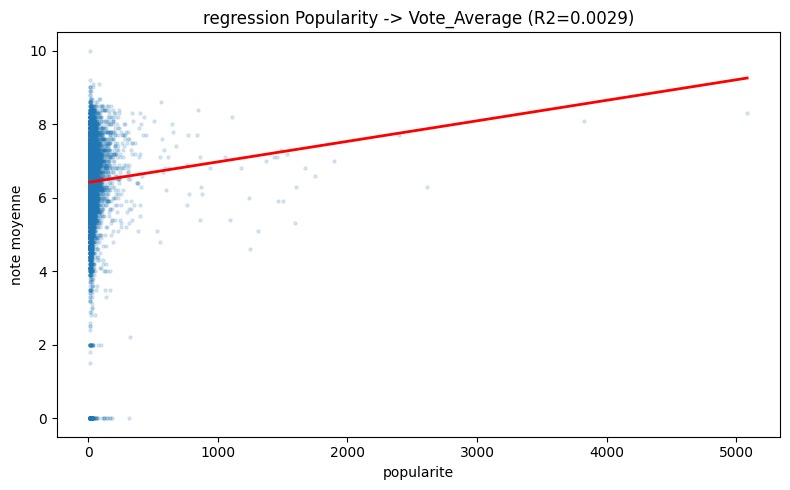

In [17]:
# regression : Popularity -> Vote_Average
clean = df.dropna(subset=["Popularity", "Vote_Average"])
x = clean["Popularity"].values
y = clean["Vote_Average"].values

slope, intercept, r_value, p_value, std_err = linregress_np(x, y)
print(f"Popularity -> Vote_Average")
print(f"pente={slope:.6f}, intercept={intercept:.4f}")
print(f"R2={r_value**2:.4f}, p={p_value:.2e}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(x, y, alpha=0.15, s=5)
x_line = np.linspace(x.min(), x.max(), 100)
ax.plot(x_line, slope * x_line + intercept, color="red", linewidth=2)
ax.set_xlabel("popularite")
ax.set_ylabel("note moyenne")
ax.set_title(f"regression Popularity -> Vote_Average (R2={r_value**2:.4f})")
plt.tight_layout()
plt.show()

year -> Vote_Average
pente=-0.012609, intercept=31.7364
R2=0.0306, p=0.00e+00


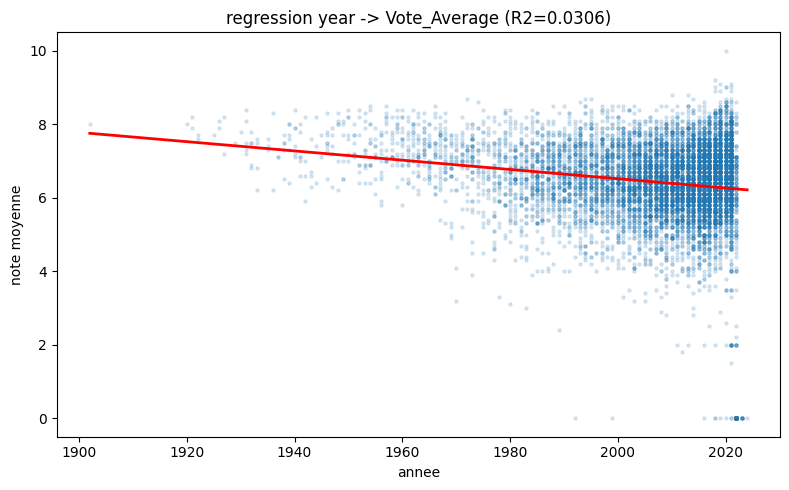

In [18]:
# regression : year -> Vote_Average
clean = df.dropna(subset=["year", "Vote_Average"])
x = clean["year"].values
y = clean["Vote_Average"].values

slope, intercept, r_value, p_value, std_err = linregress_np(x, y)
print(f"year -> Vote_Average")
print(f"pente={slope:.6f}, intercept={intercept:.4f}")
print(f"R2={r_value**2:.4f}, p={p_value:.2e}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(x, y, alpha=0.15, s=5)
x_line = np.linspace(x.min(), x.max(), 100)
ax.plot(x_line, slope * x_line + intercept, color="red", linewidth=2)
ax.set_xlabel("annee")
ax.set_ylabel("note moyenne")
ax.set_title(f"regression year -> Vote_Average (R2={r_value**2:.4f})")
plt.tight_layout()
plt.show()

Vote_Count -> Popularity
pente=0.005729, intercept=32.3431
R2=0.0189, p=0.00e+00


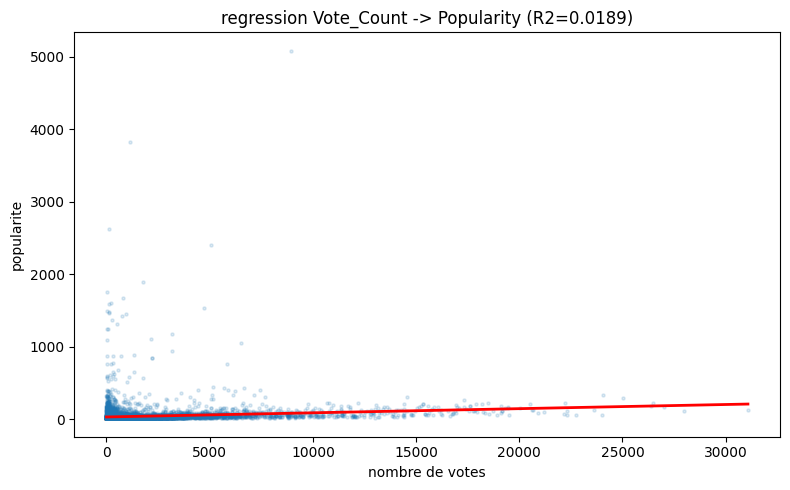

In [19]:
# regression : Vote_Count -> Popularity
clean = df.dropna(subset=["Vote_Count", "Popularity"])
x = clean["Vote_Count"].values
y = clean["Popularity"].values

slope, intercept, r_value, p_value, std_err = linregress_np(x, y)
print(f"Vote_Count -> Popularity")
print(f"pente={slope:.6f}, intercept={intercept:.4f}")
print(f"R2={r_value**2:.4f}, p={p_value:.2e}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(x, y, alpha=0.15, s=5)
x_line = np.linspace(x.min(), x.max(), 100)
ax.plot(x_line, slope * x_line + intercept, color="red", linewidth=2)
ax.set_xlabel("nombre de votes")
ax.set_ylabel("popularite")
ax.set_title(f"regression Vote_Count -> Popularity (R2={r_value**2:.4f})")
plt.tight_layout()
plt.show()

### Resume des regressions

In [20]:
# tableau recapitulatif
regressions = [
    ("Vote_Count", "Vote_Average"),
    ("Popularity", "Vote_Average"),
    ("year", "Vote_Average"),
    ("Vote_Count", "Popularity"),
]

results = []
for x_col, y_col in regressions:
    c = df.dropna(subset=[x_col, y_col])
    slope, intercept, r_val, p_val, _ = linregress_np(c[x_col], c[y_col])
    results.append({
        "x": x_col,
        "y": y_col,
        "pente": round(slope, 6),
        "R2": round(r_val**2, 4),
        "p_value": f"{p_val:.2e}"
    })

pd.DataFrame(results)

,x,y,pente,R2,p_value
0,Vote_Count,Vote_Average,0.000110,0.0643,0.00e+00
1,Popularity,Vote_Average,0.000559,0.0029,9.12e-08
2,year,Vote_Average,-0.012609,0.0306,0.00e+00
3,Vote_Count,Popularity,0.005729,0.0189,0.00e+00


## Note environnement

`scipy` n'est pas installe dans l'env (voir erreur cellule 1). Les nouvelles sections
n'utilisent que numpy / pandas / matplotlib / scikit-learn.
Si scikit-learn manque : `pip install scikit-learn`. Pour le nuage de mots : `pip install wordcloud`.

In [21]:
# imports pour les sections modelisation (cours 7 a 10)
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             accuracy_score, precision_score, recall_score,
                             f1_score, classification_report,
                             roc_curve, roc_auc_score)
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from collections import Counter
import re

RANDOM_STATE = 42

## 5. Statistiques de forme — skewness / kurtosis  *(Cours 7)*

Le cours 7 definit les attributs statistiques d'un signal : moyenne, ecart-type,
**coefficient d'asymetrie (skewness)** et **coefficient d'aplatissement (kurtosis)**.
On les applique ici a nos distributions pour quantifier leur forme
(les histogrammes de la section 2 le montraient visuellement).

In [22]:
# skewness > 0 : queue a droite (quelques films ecrasent les autres)
# kurtosis eleve : distribution pointue avec valeurs extremes
for col in ["Vote_Average", "Popularity", "Vote_Count"]:
    s = df[col].dropna()
    print(f"{col:14s} | moyenne={s.mean():8.2f} | ecart-type={s.std():8.2f} | "
          f"skewness={s.skew():6.2f} | kurtosis={s.kurt():6.2f}")

Vote_Average   | moyenne=    6.44 | ecart-type=    1.13 | skewness= -2.09 | kurtosis=  9.59
Popularity     | moyenne=   40.32 | ecart-type=  108.88 | skewness= 21.90 | kurtosis=732.71
Vote_Count     | moyenne= 1392.94 | ecart-type= 2611.30 | skewness=  4.10 | kurtosis= 22.31


/var/folders/q8/1nx6kxpx2cs5z3097z2zb9_w0000gp/T/ipykernel_5729/1844568202.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=top10, showmeans=True)


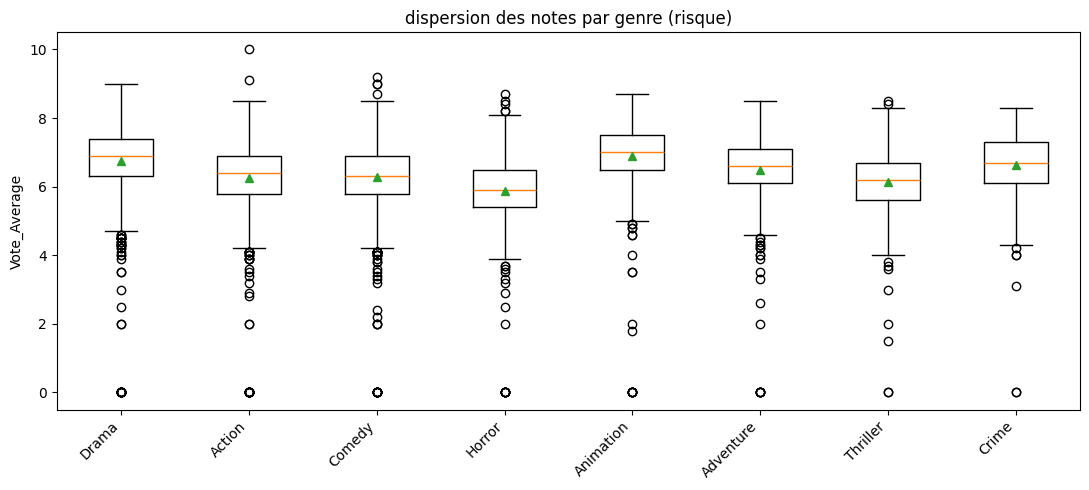

In [23]:
# boxplot : dispersion des notes par genre = genres les plus 'risques'
top10 = df["main_genre"].value_counts().head(8).index
data = [df[df["main_genre"] == g]["Vote_Average"].dropna().values for g in top10]

fig, ax = plt.subplots(figsize=(11, 5))
ax.boxplot(data, labels=top10, showmeans=True)
ax.set_title("dispersion des notes par genre (risque)")
ax.set_ylabel("Vote_Average")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 6. Reduction de dimensionnalite — PCA  *(Cours 9)*

Question : derriere nos colonnes numeriques, combien de **vraies dimensions** se cachent ?

Demarche du cours : on standardise (echelles tres differentes), on calcule la PCA
(matrice de covariance, **eigenvalues** = variance expliquee, **eigenvectors** = directions).

In [24]:
features = ["Popularity", "Vote_Count", "Vote_Average", "year"]
X = df[features].dropna()

X_std = StandardScaler().fit_transform(X)
pca = PCA().fit(X_std)

var_ratio = pca.explained_variance_ratio_
print("variance expliquee par composante :", np.round(var_ratio, 3))
print("variance cumulee                  :", np.round(np.cumsum(var_ratio), 3))

variance expliquee par composante : [0.332 0.292 0.203 0.173]
variance cumulee                  : [0.332 0.624 0.827 1.   ]


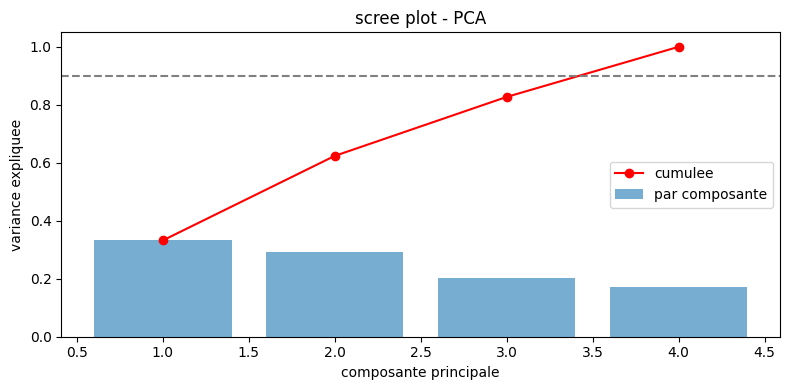

               PC1   PC2
Popularity    0.28  0.64
Vote_Count    0.64  0.21
Vote_Average  0.67 -0.21
year         -0.25  0.70


In [25]:
# scree plot : combien de composantes garder
fig, ax = plt.subplots(figsize=(8, 4))
comps = range(1, len(var_ratio) + 1)
ax.bar(comps, var_ratio, alpha=0.6, label="par composante")
ax.plot(comps, np.cumsum(var_ratio), marker="o", color="red", label="cumulee")
ax.axhline(0.9, ls="--", color="gray")
ax.set_xlabel("composante principale")
ax.set_ylabel("variance expliquee")
ax.set_title("scree plot - PCA")
ax.legend()
plt.tight_layout()
plt.show()

# eigenvectors : poids des variables sur les 2 premieres composantes
print(pd.DataFrame(pca.components_[:2].T, index=features, columns=["PC1", "PC2"]).round(2))

## 7. Classification supervisee — arbre de decision  *(Cours 8)*

On predit si un film est un **succes critique** (note >= 7.5) a partir de ses attributs,
avec un **arbre de decision**, puis on l'evalue rigoureusement.

Les classes sont desequilibrees -> occasion de montrer le **paradoxe de l'accuracy** du cours.

In [26]:
SEUIL_SUCCES = 7.5
df["succes"] = (df["Vote_Average"] >= SEUIL_SUCCES).astype(int)
print(df["succes"].value_counts(normalize=True).round(3))

# attributs predictifs (on retire Vote_Average qui definit la cible)
feat_clf = ["Popularity", "Vote_Count", "year"]
Xc = df[feat_clf].dropna()
yc = df.loc[Xc.index, "succes"]

X_train, X_test, y_train, y_test = train_test_split(
    Xc, yc, test_size=0.30, random_state=RANDOM_STATE, stratify=yc)

succes
0    0.853
1    0.147
Name: proportion, dtype: float64


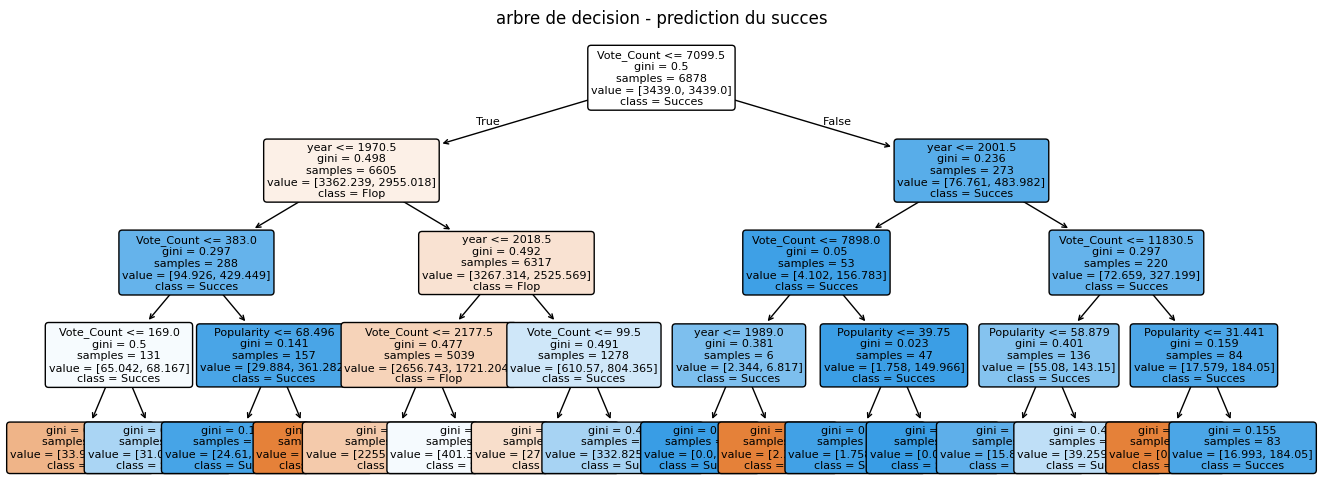

In [27]:
# arbre de decision (max_depth = elagage, evite le surapprentissage)
clf = DecisionTreeClassifier(max_depth=4, random_state=RANDOM_STATE,
                             class_weight="balanced")
clf.fit(X_train, y_train)

fig, ax = plt.subplots(figsize=(16, 6))
plot_tree(clf, feature_names=feat_clf, class_names=["Flop", "Succes"],
          filled=True, rounded=True, fontsize=8, ax=ax)
ax.set_title("arbre de decision - prediction du succes")
plt.show()

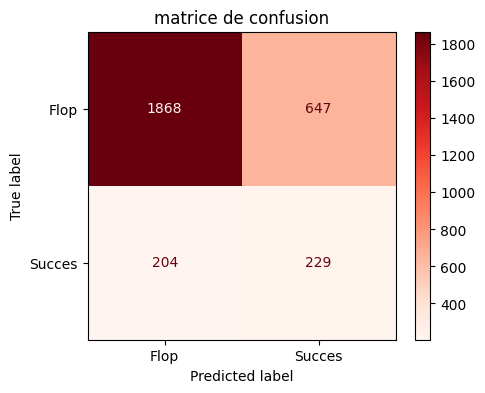

accuracy  : 0.711
precision : 0.261
rappel    : 0.529
f1-score  : 0.350

paradoxe de l'accuracy : un modele qui predit TOUJOURS 'Flop' aurait deja 85.3% d'accuracy sans rien apprendre.

              precision    recall  f1-score   support

        Flop       0.90      0.74      0.81      2515
      Succes       0.26      0.53      0.35       433

    accuracy                           0.71      2948
   macro avg       0.58      0.64      0.58      2948
weighted avg       0.81      0.71      0.75      2948



In [28]:
# evaluation
y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)[:, 1]

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm, display_labels=["Flop", "Succes"]).plot(cmap="Reds", ax=ax)
ax.set_title("matrice de confusion")
plt.show()

print(f"accuracy  : {accuracy_score(y_test, y_pred):.3f}")
print(f"precision : {precision_score(y_test, y_pred):.3f}")
print(f"rappel    : {recall_score(y_test, y_pred):.3f}")
print(f"f1-score  : {f1_score(y_test, y_pred):.3f}")
print()
print(f"paradoxe de l'accuracy : un modele qui predit TOUJOURS 'Flop' aurait deja "
      f"{(1 - y_test.mean())*100:.1f}% d'accuracy sans rien apprendre.")
print()
print(classification_report(y_test, y_pred, target_names=["Flop", "Succes"]))

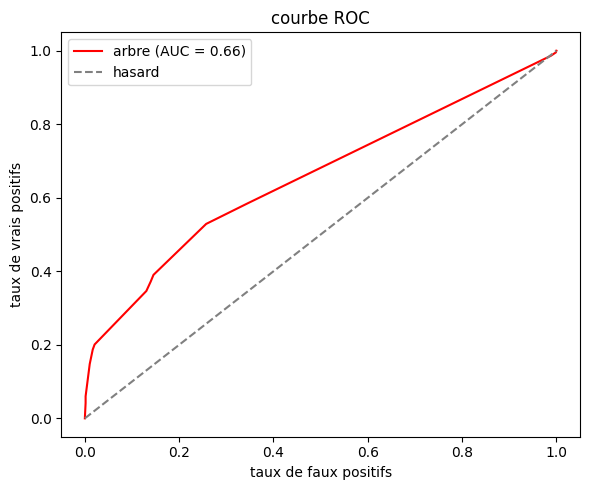

In [29]:
# courbe ROC + AUC
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color="red", label=f"arbre (AUC = {auc:.2f})")
ax.plot([0, 1], [0, 1], ls="--", color="gray", label="hasard")
ax.set_xlabel("taux de faux positifs")
ax.set_ylabel("taux de vrais positifs")
ax.set_title("courbe ROC")
ax.legend()
plt.tight_layout()
plt.show()

In [30]:
# validation croisee : la performance est-elle stable ?
scores = cross_val_score(clf, Xc, yc, cv=5, scoring="f1")
print("f1 par pli :", np.round(scores, 3))
print(f"f1 moyen   : {scores.mean():.3f} (+/- {scores.std():.3f})")

f1 par pli : [0.256 0.372 0.279 0.252 0.   ]
f1 moyen   : 0.232 (+/- 0.124)


## 8. Non-supervise — K-means + familles de films  *(Cours 10)*

Existe-t-il des **familles naturelles** de films ? On applique **K-means** et on choisit le
nombre de clusters avec la **methode du coude** et le **score de silhouette**.

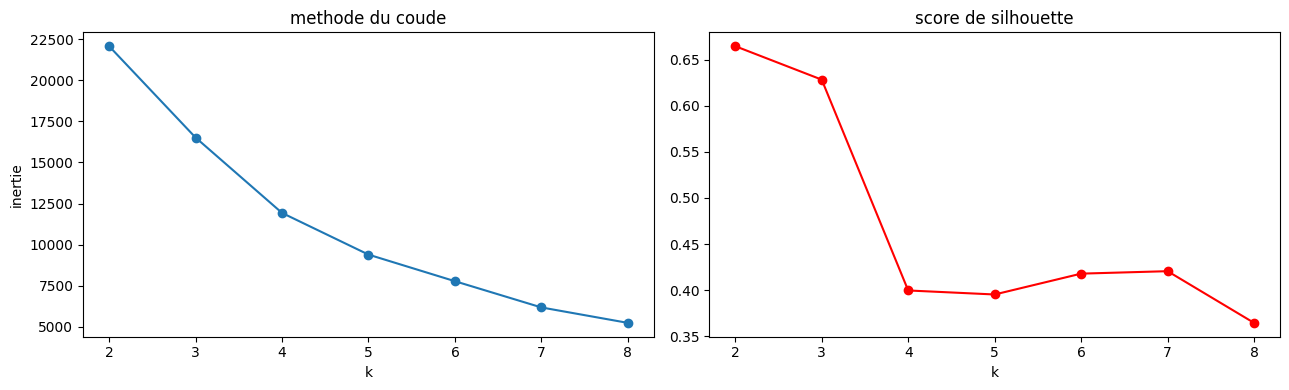

In [31]:
base = df.dropna(subset=["Popularity", "Vote_Count", "Vote_Average"]).copy()
Xk = StandardScaler().fit_transform(base[["Popularity", "Vote_Count", "Vote_Average"]])

inerties, silhouettes = [], []
Ks = range(2, 9)
for k in Ks:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit(Xk)
    inerties.append(km.inertia_)
    silhouettes.append(silhouette_score(Xk, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(list(Ks), inerties, marker="o")
axes[0].set_title("methode du coude")
axes[0].set_xlabel("k"); axes[0].set_ylabel("inertie")
axes[1].plot(list(Ks), silhouettes, marker="o", color="red")
axes[1].set_title("score de silhouette")
axes[1].set_xlabel("k")
plt.tight_layout()
plt.show()

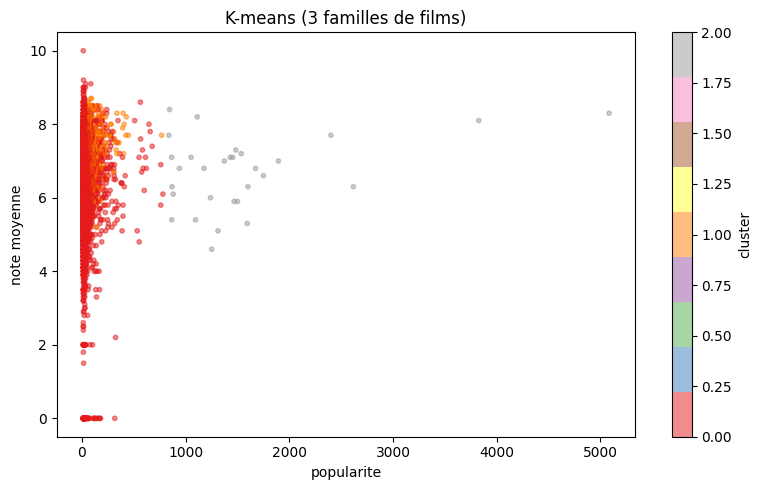

         Popularity  Vote_Count  Vote_Average
cluster                                      
0             32.11      816.96          6.37
1             83.58     9204.44          7.31
2           1568.66     1590.83          6.70


In [32]:
K_CHOISI = 3   # ajuster selon le coude / la silhouette
km = KMeans(n_clusters=K_CHOISI, random_state=RANDOM_STATE, n_init=10)
base["cluster"] = km.fit_predict(Xk)

fig, ax = plt.subplots(figsize=(8, 5))
sc = ax.scatter(base["Popularity"], base["Vote_Average"],
                c=base["cluster"], cmap="Set1", alpha=0.5, s=10)
ax.set_xlabel("popularite"); ax.set_ylabel("note moyenne")
ax.set_title(f"K-means ({K_CHOISI} familles de films)")
plt.colorbar(sc, label="cluster")
plt.tight_layout()
plt.show()

print(base.groupby("cluster")[["Popularity", "Vote_Count", "Vote_Average"]].mean().round(2))

## 9. Analyse textuelle — mots des films a succes  *(Cours 10, NLP)*

On nettoie les resumes (`Overview`) : minuscules, suppression de la ponctuation et des
stop-words, puis comptage des mots les plus frequents chez les films a succes.

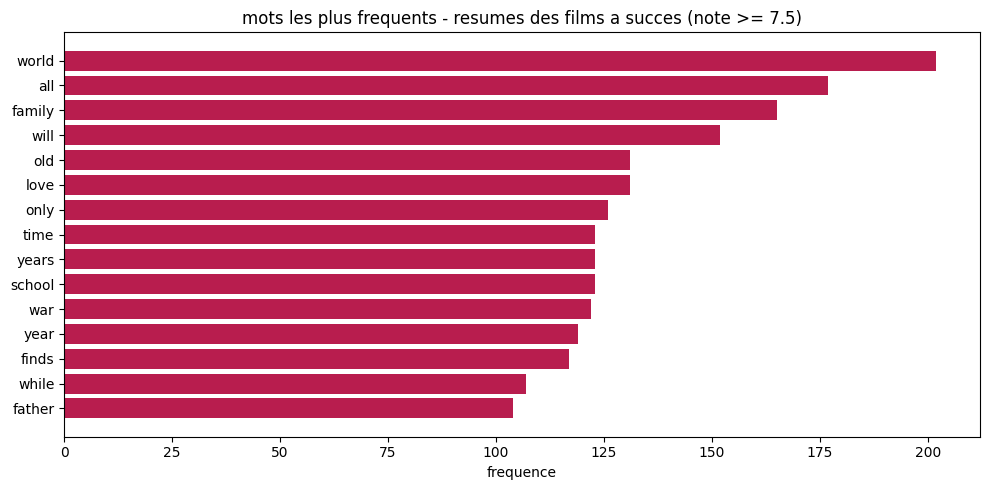

In [33]:
"""STOPWORDS = set('''the a an and or of to in on for with is are was were be been being
his her their its he she they it this that these those who what when where which film movie
as at by from into about after out up down over story life world new young man woman
one two find must finds him them you your i we our but not have has had will would can'''.split())
"""
STOPWORDS = {"the", "a", "an", "is", "am", "are", "was", "were",
    "be", "been", "being",
    "i", "you", "he", "she", "it", "we", "they",
    "me", "him", "her", "us", "them",
    "my", "your", "his", "its", "our", "their",
    "this", "that", "these", "those",
    "who", "whom", "which", "what", "whose",
    "not", "no", "nor", "and", "or", "but", "so", "yet",
    "in", "on", "at", "to", "for", "of", "with", "from", "by", "about",
    "has", "have", "had", "do", "does", "did", "'",
    "film", "movie", "story", "life", "new", "one", "two", "out", "up",
    "into", "after", "when", "where", "young", "man", "woman", "find", "must"}

def mots_frequents(series, n=15):
    texte = " ".join(series.dropna().astype(str)).lower()
    mots = re.findall(r"[a-z]+", texte)
    mots = [m for m in mots if m not in STOPWORDS and len(m) > 2]
    return Counter(mots).most_common(n)

succes_txt = df[df["Vote_Average"] >= 7.5]["Overview"]
top_mots = mots_frequents(succes_txt, 15)
mots, freqs = zip(*top_mots)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(list(mots)[::-1], list(freqs)[::-1], color="#b81d4e")
ax.set_xlabel("frequence")
ax.set_title("mots les plus frequents - resumes des films a succes (note >= 7.5)")
plt.tight_layout()
plt.show()

In [34]:
# nuage de mots optionnel (pip install wordcloud)
try:
    from wordcloud import WordCloud
    txt = " ".join(succes_txt.dropna().astype(str)).lower()
    txt = " ".join(m for m in re.findall(r"[a-z]+", txt)
                   if m not in STOPWORDS and len(m) > 2)
    wc = WordCloud(width=800, height=400, background_color="white").generate(txt)
    fig, ax = plt.subplots(figsize=(11, 5))
    ax.imshow(wc); ax.axis("off")
    ax.set_title("nuage de mots - films a succes")
    plt.show()
except ImportError:
    print("pour le nuage de mots : pip install wordcloud")

pour le nuage de mots : pip install wordcloud


## Conclusion — portrait-robot du film a produire

A completer avec **vos** resultats reels apres execution. Trame d'analyse business :

- **Definir le succes** : popularite et note sont peu correlees (section 3) -> un hit doit
  viser les deux ; le nombre de votes stabilise la note.
- **Forme des donnees** (section 5) : skewness/kurtosis confirment que quelques films
  ecrasent les autres en popularite.
- **Genres** : privilegier les genres a note moyenne elevee ET faible dispersion (section 5,
  boxplot) -> moins risques.
- **Dimensions cachees** (PCA, section 6) : nos variables se resument a ~2 axes.
- **Predictibilite** (section 7) : le succes critique est-il previsible ? AUC/F1 le disent, et
  le paradoxe de l'accuracy rappelle de ne jamais se fier a l'accuracy seule.
- **Familles** (section 8) + **mots-cles** (section 9) : profils-types et signature thematique
  des films a recommander.

**Notions de cours couvertes :** C7 (stats, skewness/kurtosis, correlation) · C8 (arbre de
decision, matrice de confusion, accuracy & paradoxe, precision/rappel/F1, ROC/AUC, validation
croisee, elagage) · C9 (valeurs manquantes, variance, correlation inter-attributs, PCA) ·
C10 (K-means, coude, silhouette, NLP/nuage de mots). La regression lineaire (section 4) est un
bonus hors des 4 cours cibles.
